 # Mão na massa: realizando a classificação com outro dataset

In [2]:
# 1. Ler a URL utilizando a biblioteca pandas e armazenar os dados em uma variável.
import pandas as pd 
url = 'https://raw.githubusercontent.com/alura-cursos/classificacao_multiclasse/main/Dados/df_vinho.csv'
dados = pd.read_csv(url)
dados.head()

,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,mediano
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,mediano
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,mediano
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,mediano
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,mediano


In [3]:
# 2. Visualizar o DataFrame para verificar a presença de dados nulos e determinar se é necessário realizar algum pré-processamento.
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   acidez fixa                1359 non-null   float64
 1   acidez volátil             1359 non-null   float64
 2   ácido cítrico              1359 non-null   float64
 3   açúcar residual            1359 non-null   float64
 4   cloretos                   1359 non-null   float64
 5   dióxido de enxofre livre   1359 non-null   float64
 6   dióxido de enxofre total   1359 non-null   float64
 7   densidade                  1359 non-null   float64
 8   pH                         1359 non-null   float64
 9   sulfatos                   1359 non-null   float64
 10  álcool                     1359 non-null   float64
 11  qualidade                  1359 non-null   object 
dtypes: float64(11), object(1)
memory usage: 127.5+ KB


In [4]:
# 3. Separar as features em uma variável X e a coluna-alvo em uma variável y.
X = dados.drop(columns='qualidade')
y = dados['qualidade']

In [5]:
# 4. Dividir os dados em conjuntos de treinamento, validação e teste.
from sklearn.model_selection import train_test_split
X, X_teste, y, y_teste = train_test_split(X, y, test_size=0.30, random_state=40, shuffle=True, stratify=y)
X_treino, X_val, y_treino, y_val = train_test_split(X, y, test_size=0.30, random_state=40, shuffle=True, stratify=y)

In [6]:
# 5. Treinar o algoritmo de classificação Random Forest utilizando os dados de treinamento.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=50, random_state=40)
rf.fit(X_treino, y_treino)
y_pred = rf.predict(X_val)
print(f'Acurácia de Treino: {rf.score(X_treino, y_treino)}')
print(f'Acurácia de Validação: {rf.score(X_val, y_val)}')

Acurácia de Treino: 1.0
Acurácia de Validação: 0.8181818181818182


Relatório de Classificação: 
               precision    recall  f1-score   support

         bom       0.44      0.62      0.52        39
     mediano       0.88      0.82      0.85       234
        ruim       0.20      0.23      0.21        13

    accuracy                           0.77       286
   macro avg       0.51      0.56      0.53       286
weighted avg       0.79      0.77      0.78       286



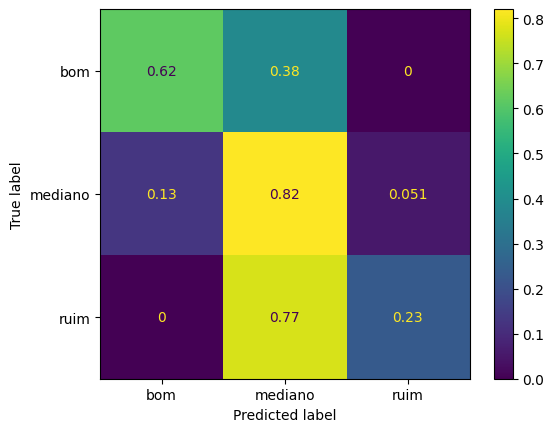

In [17]:
# 6. Avaliar o desempenho do modelo por meio da matriz de confusão e de um relatório de métricas.
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report

report = classification_report(y_true=y_val, y_pred=y_pred)
print(f'Relatório de Classificação: \n {report}')
matriz_confusao = confusion_matrix(y_true=y_val, y_pred=y_pred)
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', display_labels=rf.classes_);


              precision    recall  f1-score   support

         bom       0.44      0.62      0.52        39
     mediano       0.88      0.82      0.85       234
        ruim       0.20      0.23      0.21        13

    accuracy                           0.77       286
   macro avg       0.51      0.56      0.53       286
weighted avg       0.79      0.77      0.78       286



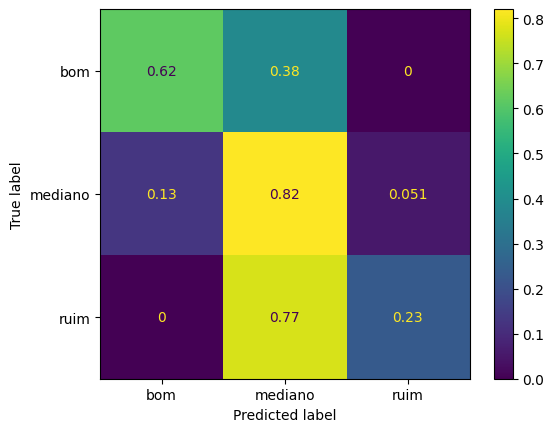

In [18]:
#7. Avaliar a necessidade de balanceamento dos dados. Caso seja necessário, realizar o balanceamento e treinar o modelo novamente.
# y_treino.value_counts()
# qualidade
# mediano    544
# bom         90
# ruim        31

from imblearn.over_sampling import SMOTE

oversample = SMOTE(random_state=40)
X_balanceado, y_balanceado = oversample.fit_resample(X_treino, y_treino)
y_balanceado.value_counts()

rf = RandomForestClassifier(max_depth=50, random_state=40)
rf.fit(X_balanceado, y_balanceado)
y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', display_labels=rf.classes_);

In [ ]:
# 8. Realizar validação cruzada para garantir a robustez do modelo
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

rf = RandomForestClassifier(max_depth=50, random_state=40)
pipeline = imbpipeline([('oversample', SMOTE()), ('florestas', rf)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring='recall_weighted')
cv_resultados['test_score']

array([0.7382199 , 0.76842105, 0.72631579, 0.78947368, 0.75789474])

              precision    recall  f1-score   support

         bom       0.50      0.65      0.57        55
     mediano       0.90      0.82      0.86       334
        ruim       0.26      0.42      0.32        19

    accuracy                           0.78       408
   macro avg       0.55      0.63      0.58       408
weighted avg       0.82      0.78      0.80       408



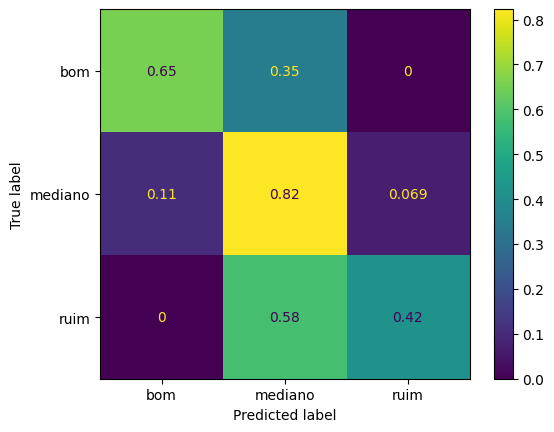

In [22]:
# 9. Testar o modelo com dados de teste que nunca foram previamente observados pelo modelo.
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X, y)
rf = RandomForestClassifier(random_state=0, max_depth=10)
rf.fit(X_balanceado, y_balanceado)
y_pred = rf.predict(X_teste)

print(classification_report(y_teste, y_pred))
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred, normalize='true', display_labels=rf.classes_);